## **Tipos de regresión**
* Lineal (simple y múltiple)
* Polinómica
* Logística

---

## **Regresión Lineal Múltiple**

* **Extensión de regresión lineal simple:** múltiples atributos (variables independientes).


$$y = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

* $b_0 \rightarrow$ es la intersección.
* $b_1, b_2, \dots, b_n \rightarrow$ coeficientes de las variables independientes.

---

**1. Nivel Nativo (Python puro)**

En regresión múltiple, lo más eficiente "a mano" es usar la Ecuación Normal con matrices: $\mathbf{B} = (X^T X)^{-1} X^T Y$.

In [ ]:
import numpy as np

# Datos: [Horas, Asistencia]
X = np.array([[1, 50], [2, 62], [3, 70], [4, 83], [5, 90]])
# Calificaciones
y = np.array([40, 50, 60, 70, 80])

# Añadimos una columna de 1s para el término de intersección (b0)
X_b = np.c_[np.ones((5, 1)), X]

# Entrenamiento: Ecuación Normal
beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Nuevo valor: 6 horas y 95% asistencia
nuevo_dato = np.array([1, 6, 95])
prediccion = nuevo_dato.dot(beta)

print(f"Coeficientes: {beta}")
print(f"Predicción: {prediccion:.2f}")

Coeficientes: [3.00000000e+01 1.00000000e+01 1.72306613e-13]
Predicción: 90.00


---
**2. TensorFlow (Nivel Bajo)**

Aquí el modelo aprende los coeficientes de un vector de pesos $W$ y un sesgo $b$.

In [ ]:
import tensorflow as tf

X = tf.constant([[1., 50.], [2., 60.], [3., 70.], [4., 80.], [5., 90.]], dtype=tf.float32)
y = tf.constant([[40.], [50.], [60.], [70.], [80.]], dtype=tf.float32)

# W tiene 2 pesos (uno por variable), b es la intersección
W = tf.Variable(tf.random.normal([2, 1]))
b = tf.Variable(tf.random.normal([1]))

opt = tf.optimizers.SGD(learning_rate=0.0001)

for _ in range(2000):
    with tf.GradientTape() as tape:
        y_pred = tf.matmul(X, W) + b
        loss = tf.reduce_mean(tf.square(y - y_pred))
    grads = tape.gradient(loss, [W, b])
    opt.apply_gradients(zip(grads, [W, b]))

# Predicción
nuevo_x = tf.constant([[6., 95.]])
prediccion = tf.matmul(nuevo_x, W) + b
print(f"Predicción para 6h y 95% asistencia: {prediccion.numpy()[0][0]:.2f}")

Predicción para 6h y 95% asistencia: 83.55


---
**3. Keras (Nivel Alto)**

Es casi idéntico al simple, solo cambiamos el input_shape para aceptar las 2 variables de entrada.

In [ ]:
from tensorflow import keras
import numpy as np

X = np.array([[1, 50], [2, 60], [3, 70], [4, 80], [5, 90]], dtype=float)
y = np.array([40, 50, 60, 70, 80], dtype=float)

model = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[2]) # 2 neuronas de entrada
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=1000, verbose=0)

# Nuevo cálculo
print(f"Predicción Keras: {model.predict(np.array([[6, 95]]))[0][0]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicción Keras: 81.02


---
**4. Scikit-Learn (Nivel Analítico)**

La belleza de Scikit-Learn es que el código es prácticamente el mismo que el de la regresión simple; la librería detecta automáticamente que hay múltiples columnas en $X$.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# X con dos columnas: Horas y Asistencia
X = np.array([[1, 50], [2, 60], [3, 70], [4, 80], [5, 90]])
y = np.array([40, 50, 60, 70, 80])

modelo = LinearRegression()
modelo.fit(X, y) # El modelo entrena con n variables

# Predecir un nuevo valor
nuevo_x = [[6, 95]]
prediccion = modelo.predict(nuevo_x)

print(f"Intersección (b0): {modelo.intercept_}")
print(f"Coeficientes (b1, b2): {modelo.coef_}")
print(f"Predicción Final: {prediccion[0]:.2f}")

Intersección (b0): -9.603960396039625
Coeficientes (b1, b2): [0.0990099  0.99009901]
Predicción Final: 85.05


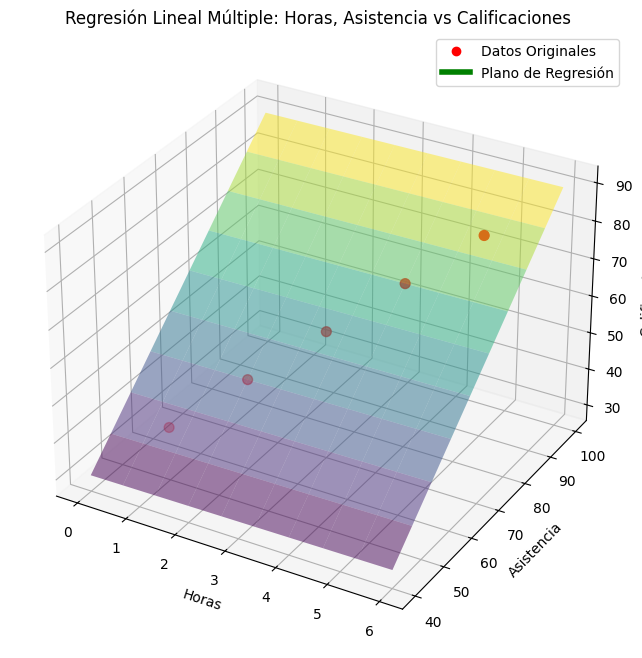

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.linear_model import LinearRegression

# Re-define X and y from the Scikit-learn section for clarity
X = np.array([[1, 50], [2, 60], [3, 70], [4, 80], [5, 90]])
y = np.array([40, 50, 60, 70, 80])

# Re-train the model to ensure access to coefficients
modelo = LinearRegression()
modelo.fit(X, y)

# Extract coefficients and intercept
b0 = modelo.intercept_
b1, b2 = modelo.coef_

# Create a figure and a 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points
ax.scatter(X[:, 0], X[:, 1], y, color='red', s=50, label='Datos Originales')

# Create a meshgrid for the regression plane
x1_surf = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 10)
x2_surf = np.linspace(X[:, 1].min() - 10, X[:, 1].max() + 10, 10)
x1_surf, x2_surf = np.meshgrid(x1_surf, x2_surf)

# Calculate the corresponding y values for the plane
y_surf = b0 + b1 * x1_surf + b2 * x2_surf

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.5, cmap='viridis', label='Plano de Regresión')

# Set labels and title
ax.set_xlabel('Horas')
ax.set_ylabel('Asistencia')
ax.set_zlabel('Calificaciones')
ax.set_title('Regresión Lineal Múltiple: Horas, Asistencia vs Calificaciones')

# Add a legend, adjusting for plot_surface not having a direct legend handle
# This is a workaround for 3D plot_surface legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='red', marker='o', linestyle='None'),
                Line2D([0], [0], color='green', lw=4)] # Green to represent the plane
ax.legend(custom_lines, ['Datos Originales', 'Plano de Regresión'])

plt.show()